In [ ]:
seq_length = 150
reads_data_path = "/home/luna.kuleuven.be/u0169940/Data/Loyfer/TrainingDataWithRejection_hg38_mincpg_4_minlen_10/"
dmr_label_column = "dmr_ctype_label"
mincpg_pointer = reads_data_path.find("mincpg_")
classifier_model_path = f"../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_{dmr_label_column}_{reads_data_path[mincpg_pointer:]}"

In [36]:
import pickle
import numpy as np
import pandas as pd

In [3]:
with open(
    f"{classifier_model_path}/methylbert_deconv_prepared_splits_hg38.pkl", "rb"
) as f:
    train_split_uxm_input, valid_split_uxm_input, test_split_uxm_input = pickle.load(f)

In [5]:
from methyldl.deconvolution.uxm import load_atlas, decon_single_samp

atlas_location = "../../UXM_deconv/supplemental/Atlas.U25.l4.hg38.full.tsv"
atlas, ref_cells = load_atlas(atlas_location)

In [12]:
target_columns = [f"prediction_{i}" for i in range(0, 40)]

In [58]:
all_data = pd.concat(
    [train_split_uxm_input, valid_split_uxm_input, test_split_uxm_input], axis=0
)

In [59]:
all_data["prediction"] = np.argmax(all_data[target_columns], 1)
all_data["confidence"] = np.max(all_data[target_columns], 1)

In [60]:
from sklearn.metrics import matthews_corrcoef as mcc

In [65]:
per_region_mccs = test_split_uxm_input.groupby(["dmr_ctype", "name"]).apply(
    lambda x: mcc(y_true=x["label"], y_pred=x["prediction"])
)

/home/luna.kuleuven.be/u0169940/.cache/pypoetry/virtualenvs/methyldl-GStZGe-R-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/luna.kuleuven.be/u0169940/.cache/pypoetry/virtualenvs/methyldl-GStZGe-R-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/luna.kuleuven.be/u0169940/.cache/pypoetry/virtualenvs/methyldl-GStZGe-R-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known label

In [66]:
per_region_mccs = per_region_mccs.reset_index()
per_region_mccs.columns = ["dmr_ctype", "name", "mcc"]

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_sorted_mcc_boxplots(df, threshold=None):
    """
    Generates a boxplot of MCC scores grouped by cell type,
    sorted from highest median MCC to lowest.

    Parameters:
    - df: Pandas DataFrame containing 'dmr_ctype' and 'mcc' columns.
    - threshold: Optional float (e.g., 0.5) to draw a horizontal reference line.
    """
    # 1. Calculate medians and determine the sort order
    medians = df.groupby("dmr_ctype")["mcc"].median().sort_values(ascending=False)
    sorted_cell_types = medians.index.tolist()

    # 2. Set up the figure (wide enough for ~39 cell types)
    plt.figure(figsize=(18, 8))

    # 3. Create the Boxplot
    sns.boxplot(
        data=df, x="dmr_ctype", y="mcc", order=sorted_cell_types, palette="viridis"
    )

    # 4. Add a horizontal threshold line if provided
    if threshold is not None:
        plt.axhline(
            y=threshold,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Threshold ({threshold})",
        )
        plt.legend(loc="upper right", fontsize=12)

    # 5. Prettify the axes and labels
    plt.title(
        "MCC Scores per Cell Type Specific Regions (Sorted by Median)",
        fontsize=18,
        pad=15,
    )
    plt.xlabel("Cell Type", fontsize=14)
    plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=14)

    # Rotate the x-axis labels 90 degrees to prevent text overlap
    plt.xticks(rotation=90, fontsize=10)

    # Adjust layout so the bottom labels aren't cut off
    plt.tight_layout()

    # Save and show
    plt.savefig("mcc_boxplots_sorted.png", bbox_inches="tight", dpi=300)
    plt.show()

/tmp/ipykernel_507683/3443351785.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


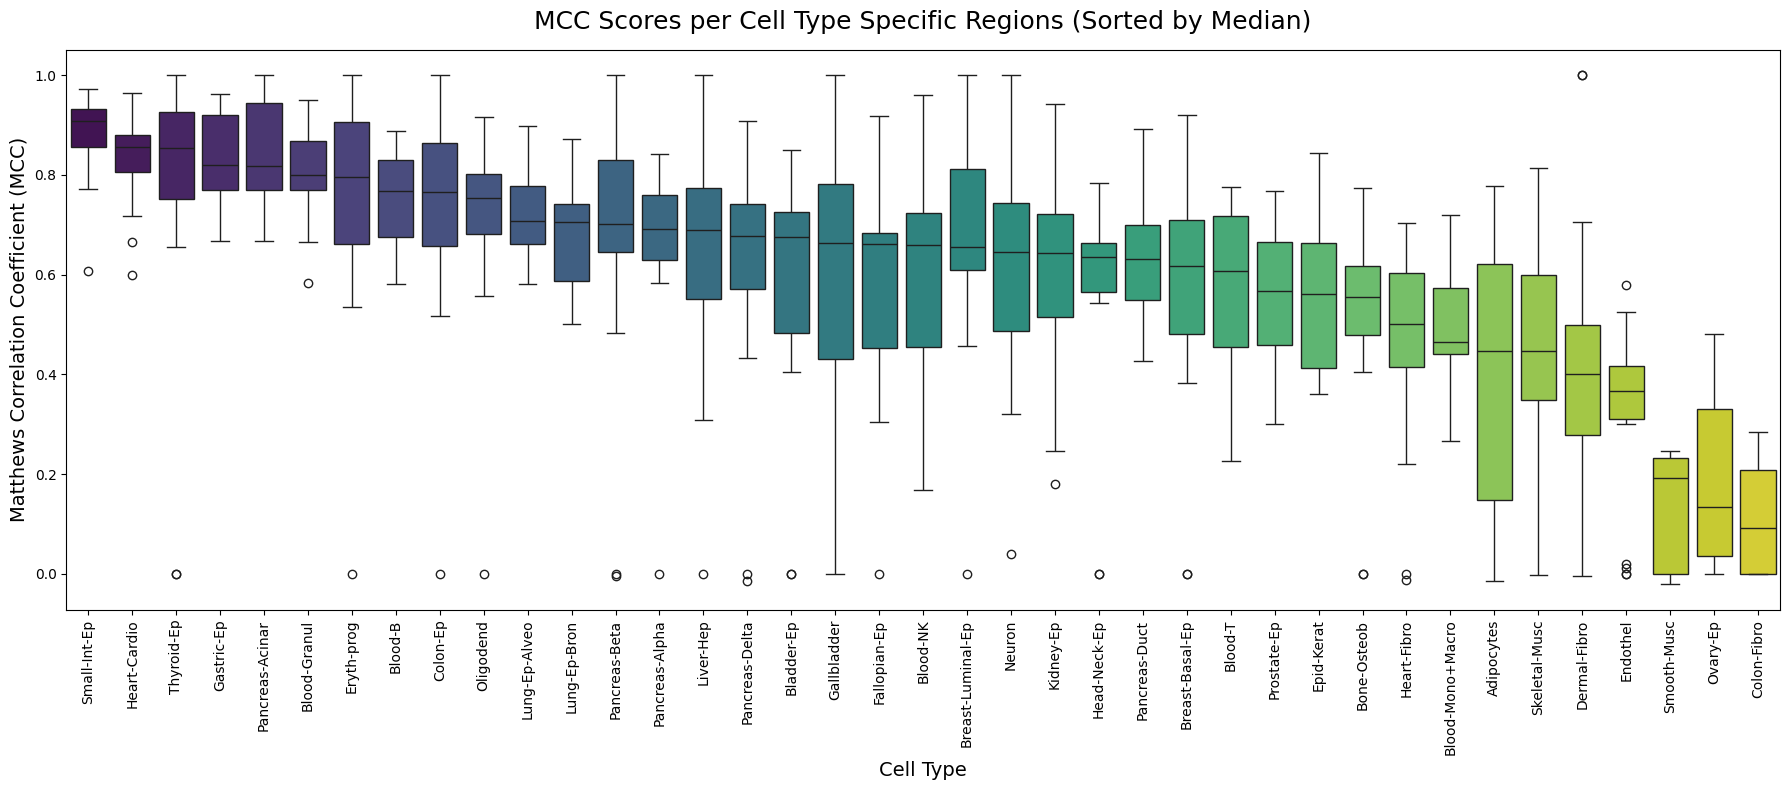

In [67]:
plot_sorted_mcc_boxplots(per_region_mccs)

In [68]:
with open("per_region_mccs_test.pkl", "wb") as f:
    pickle.dump(per_region_mccs, f)